Heatmap сохранён как 'steam_tag_trends_heatmap.png'

Результаты также сохранены в файл: analysis_results.txt


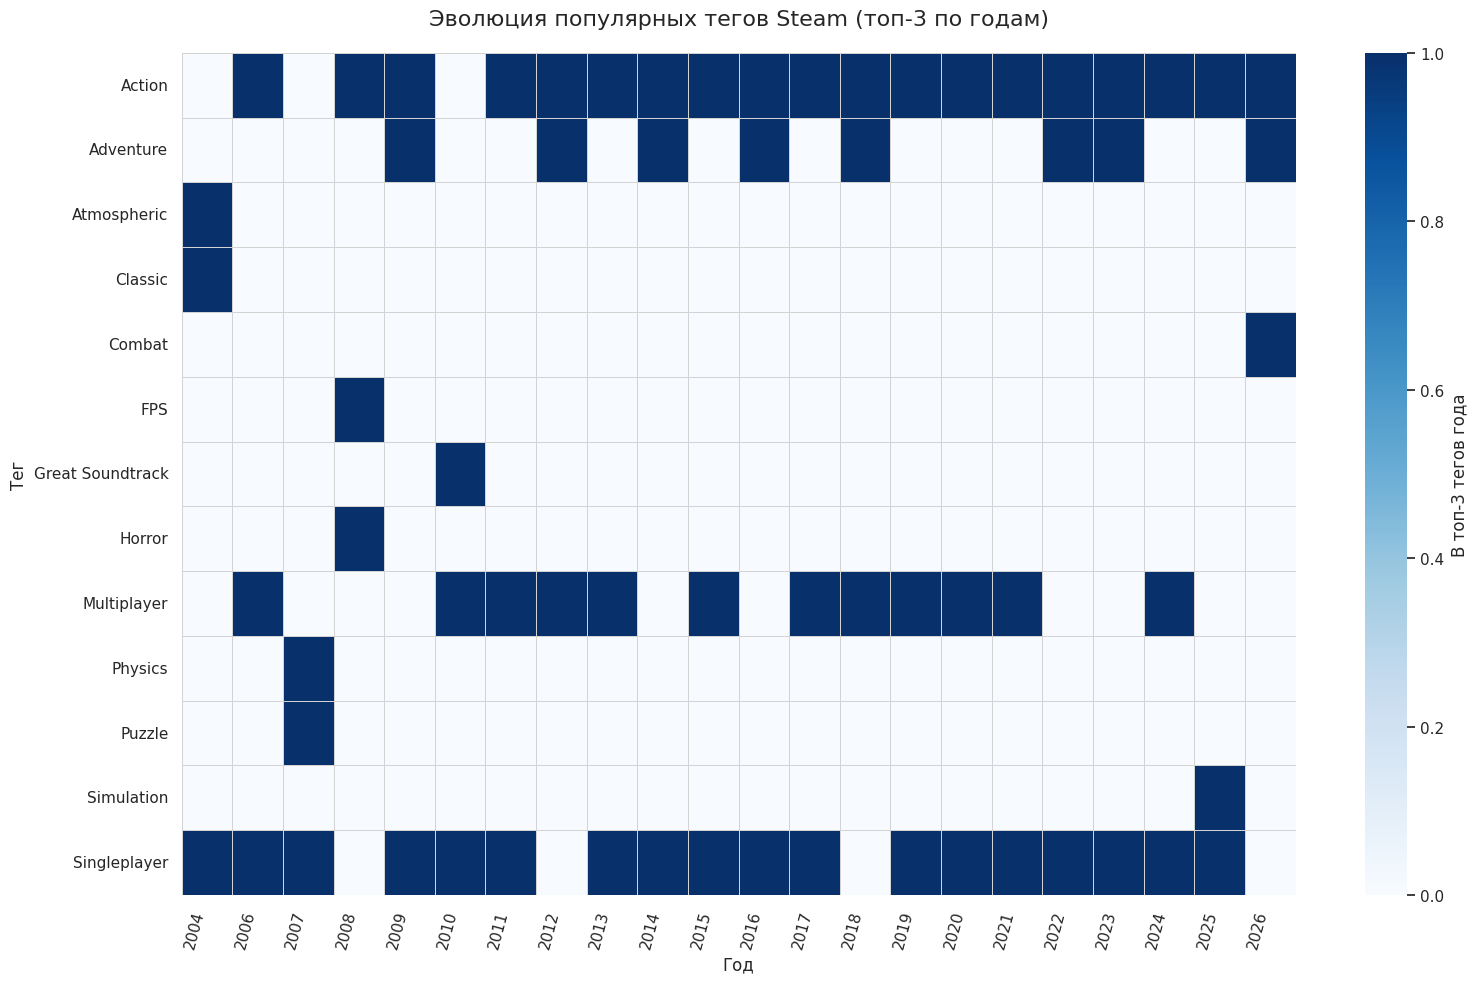

In [4]:
# analyzer_with_heatmap
import json
import pandas as pd
from collections import Counter
import re
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


# 1. Вспомогательная функция
def parse_year(date_str):
    if not date_str:
        return None
    match = re.search(r'\b(19|20)\d{2}\b', date_str)
    return int(match.group()) if match else None


# 2. Загрузка и предварительная обработка
with open('steam_top_1000.json', 'r', encoding='utf-8') as f:
    data = json.load(f)

data = data[:1000]
df = pd.DataFrame(data)

df['year'] = df['release_date'].apply(parse_year)
df = df.dropna(subset=['year']).copy()
df['year'] = df['year'].astype(int)
df = df[df['tags'].apply(lambda x: isinstance(x, list) and len(x) > 0)]


# 3. Анализ по годам (только информативные годы)
results = {}

for year, group in df.groupby('year'):
    if len(group) < 2:
        continue

    all_tags = [tag for tags in group['tags'] for tag in tags]
    if not all_tags:
        continue

    tag_counts = Counter(all_tags)
    if max(tag_counts.values()) == 1:
        continue

    most_common = [tag for tag, _ in tag_counts.most_common(3)]
    results[year] = {'most_popular_tags': most_common}


# 4. Подготовка данных для heatmap

# Собираем все теги из топ-3
all_popular_tags = set()
for info in results.values():
    all_popular_tags.update(info['most_popular_tags'])
all_popular_tags = sorted(all_popular_tags)
years = sorted(results.keys())

# Создаём DataFrame: строки — годы, столбцы — теги
heatmap_data = pd.DataFrame(0, index=years, columns=all_popular_tags, dtype=int)

# Заполняем: 1 = тег в топ-3 этого года
for year in years:
    tags = results[year]['most_popular_tags']
    for tag in tags:
        heatmap_data.loc[year, tag] = 1

# Опционально: можно использовать ранг (1, 2, 3) вместо 1
# Но для heatmap проще бинарный признак

# 5. Построение heatmap
plt.figure(figsize=(16, 10))
sns.set(style="white")
ax = sns.heatmap(
    heatmap_data.T,               # транспонируем: годы по X, теги по Y
    cmap="Blues",
    cbar_kws={'label': 'В топ-3 тегов года'},
    linewidths=0.5,
    linecolor='lightgray'
)

plt.title("Эволюция популярных тегов Steam (топ-3 по годам)", fontsize=16, pad=20)
plt.xlabel("Год", fontsize=12)
plt.ylabel("Тег", fontsize=12)
plt.xticks(rotation=75, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()
plt.savefig("steam_tag_trends_heatmap.png", dpi=200, bbox_inches='tight')
print("Heatmap сохранён как 'steam_tag_trends_heatmap.png'")

# показать график
# plt.show()


# 6. Сохранение текстового отчёта 2
output_lines = []

# Здесь можно добавить полный текстовый анализ,для краткости оставим только уведомление.
output_lines.append("Текстовый отчёт можно расширить по желанию.")
output_lines.append(f"Проанализировано {len(results)} информативных лет.")

with open('analysis_results_1.txt', 'w', encoding='utf-8') as f:
    f.write('\n'.join(output_lines))

print("\nРезультаты также сохранены в файл: analysis_results.txt")